In [1]:
from loadmodules import *
import specKit   
import warnings
warnings.filterwarnings('ignore')
import utilities 
import kepler
import seaborn as sns
import figureMarkup

def display_dataframe(df):
    print(df.to_string(index=False, line_width=1000))

<Figure size 640x480 with 0 Axes>

In [2]:
pathFullSample = "../Data/FinalCombinedData.csv"
Lremovefaintstars = True
LcrossmatchWright2011=True
LcrossmatchFang2018=True
teff_min, teff_max = 4000, 7000
ethreshold = 0.03
pthreshold = 0.3
CaIIKLambda0 = 3933.664                 # CaII K line wavelength in air
CaIIHLambda0 = 3968.470                 # CaII H line wavelength in air


# remove faint stars.

In [3]:
#############################################################################################################
# # load orbital pereriods and rotation periods for demonstrating the synchronization.
fullSample = pd.read_csv(pathFullSample)
fullSample = fullSample[fullSample.teff.between(teff_min, teff_max)].reset_index(drop=True)
fullSample = fullSample[fullSample.logg>3.5].reset_index(drop=True)
if Lremovefaintstars: fullSample = fullSample[fullSample.Gmag<13].reset_index(drop=True)

############################################################################################################
# load Kepler/K2 rotation sample
filename = "../Data/FullRotationSamplebyKeplerK2.csv"
rotator = pd.read_csv(filename).drop_duplicates(subset=["starid"]).reset_index(drop=True)
rotator.drop(columns=["ra", "dec"], inplace=True)
rotator.rename(columns={"starid":"starID"}, inplace=True)
rotator = pd.merge(rotator, fullSample, on="source_id").reset_index(drop=True)
rotator = rotator[rotator.teff.between(teff_min, teff_max)].reset_index(drop=True)
rotator.dropna(subset=["logrRprimehk"], inplace=True)
rotator = rotator[rotator.ref!="gaulme20"].reset_index(drop=True)
print("Number of Kepler/K2 rotators: {:d}".format(len(rotator)))
rotator = rotator[rotator.period.isna()].reset_index(drop=True)
print("Number of Kepler/K2 rotators with Gaia binary systems removed: {:d}".format(len(rotator)))

#############################################################################################################
# load the reference sample from Wright et al. 2011 and Fang et al. 2018
calibrator = pd.read_csv("../Data/ReferenceSample.csv")
calibrator = pd.merge(calibrator, fullSample, on="source_id").rename(columns={"starid":"starID"})
calibrator = calibrator[calibrator.teff.between(teff_min, teff_max)].reset_index(drop=True)
calibrator = calibrator[['starID', 'source_id', 'Prot', 'SIndex', 'logrRprimehk', 'logrRprimehkerr', 'Teff', 'teff', 'teff_err', 'ref']]

############################################################################################################
# load orbital pereriods and rotations periods for demonstrating the synchronization.
sync = pd.read_csv("../Data/SynchronisationKeplerK2Sample.csv")
sync = sync[sync.ref!="gaulme20"].reset_index(drop=True)
print("Number of systems with Prot and Porb: {:d}".format(len(sync.drop(columns=["Porb", "Prot"]))))
n_short_bin = len(sync[(sync.Porb<10)])
n_short_bin_sync = len(sync[(sync.Porb<10)&(0.5<sync.Porb/sync.Prot)&(sync.Porb/sync.Prot<2)])
print("The fraction of non-synchronised systems: {:.3f}".format(1-n_short_bin_sync/n_short_bin))

Number of Kepler/K2 rotators: 6295
Number of Kepler/K2 rotators with Gaia binary systems removed: 6015
Number of systems with Prot and Porb: 1409
The fraction of non-synchronised systems: 0.108


Saturated logR'HK: -3.947+/-0.014
Number of rotators stars: 6015
median uncertainties (with activiy variablity) for logR'HK of single stars: 0.088
median formal uncertainties (without activiy variablity) for logR'HK of single stars: 0.055
Number of binary stars shown in this figure: 1033
Max logR'HK of binary stars is -3.832
747 SB binaries
286 eclipsing binaries
median uncertainties (with activiy variablity) for logR'HK of binary stars: 0.078
median formal uncertainties (without activiy variablity) for logR'HK of binary stars: 0.032
enhancement is 0.42 times formal uncertainty
enhancement is 2.29 times conservative uncertainty


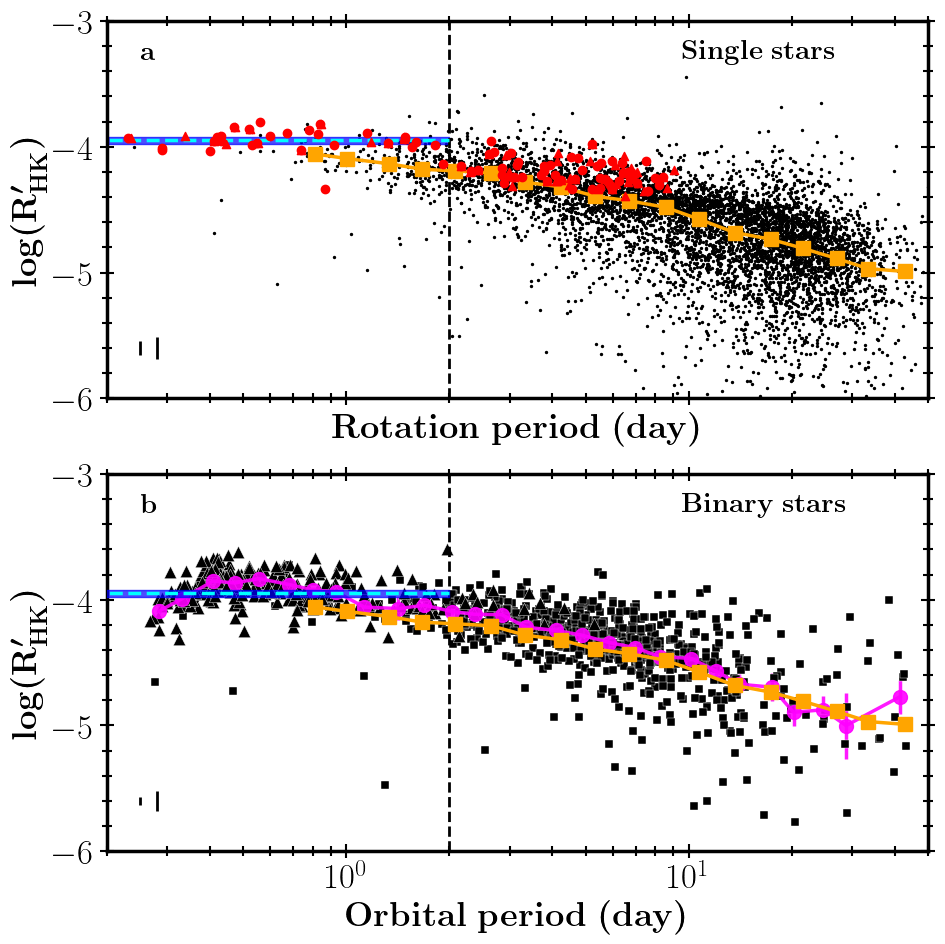

In [4]:
# calculate statistics and fit a line to the data
logRprimeHKSat = calibrator[calibrator.Prot<2].logrRprimehk.mean()
logRprimeHKSatErr = calibrator[calibrator.Prot<2].logrRprimehk.std()/np.sqrt(len(calibrator[calibrator.Prot<2]))
ErrInflationFactor = 2
print(f"Saturated logR'HK: {logRprimeHKSat:.3f}+/-{logRprimeHKSatErr:.3f}")
print("Number of rotators stars: {:d}".format(len(rotator[rotator.Prot.notna() & rotator.logrRprimehk.notna()])))

# calculate statistics and fit a line to the data
x = np.log10(rotator[~rotator.logrRprimehk.isna()].Prot.values)
y = rotator[~rotator.logrRprimehk.isna()].logrRprimehk.values
stat_rot_rhk = kepler.bin(x=x, y=y, bins=np.linspace(-0.15, 1.8, 20), suffixes=["P", "S"], LdivideN=True)
stat_rot_rhk = stat_rot_rhk.apply(pd.to_numeric)
stat_rot_rhk = stat_rot_rhk[(-2<stat_rot_rhk.median_P)&(stat_rot_rhk.median_P<1.7)&(stat_rot_rhk.N>10)]
shortP = pd.concat([rotator[["Prot", "logrRprimehk", "logrRprimehkerr"]], calibrator[["Prot", "logrRprimehk", "logrRprimehkerr"]]], axis=0, ignore_index=True)


# plot Prot vs Sindex
fig, ax = plt.subplots(2,1, figsize=(10,10), sharex=True, sharey=True)
ax[0].plot([0, 10**pthreshold], [logRprimeHKSat, logRprimeHKSat], c="cyan", ls="--", lw=2.5, zorder=3)
ax[0].fill_between([0, 10**pthreshold], y1=logRprimeHKSat-logRprimeHKSatErr*ErrInflationFactor, y2=logRprimeHKSat+logRprimeHKSatErr*ErrInflationFactor, color="blue", alpha=0.7, zorder=2)
ax[0].scatter(rotator.Prot, rotator.logrRprimehk, c="k", s=2, zorder=1)
ax[0].scatter(calibrator[calibrator.ref=="fang18"].Prot, calibrator[calibrator.ref=="fang18"].logrRprimehk, marker="^", s=35, c="r", zorder=4)
ax[0].scatter(calibrator[calibrator.ref=="wright11"].Prot, calibrator[calibrator.ref=="wright11"].logrRprimehk, marker="o", s=36, c="r", zorder=4)
ax[0].errorbar(10**stat_rot_rhk.median_P, stat_rot_rhk.median_S, marker="s", yerr=stat_rot_rhk.std_S, c="orange", zorder=3, lw=2.5, ms=10)
ax[0].set_ylabel(r"$\boldsymbol{\rm \log (R'_{HK})}$")
ax[0].set_xlabel(r"$\boldsymbol{\rm Rotation~period~(day)}$")
ax[0].errorbar([0.25], [-5.6], yerr=rotator.logrRprimehkerr.median(), c="k", zorder=12, ms=5, lw=2, marker='none')
ax[0].errorbar([0.28], [-5.6], yerr=rotator.logrRprimehkerrUniform.median(), c="k", zorder=12, ms=5, lw=2, marker='none')
kepler.figure_annotation(ax[0], text=[r"$\boldsymbol{\rm Single~stars}$"], fontsize=20, coords=[0.7, 0.90])
kepler.figure_annotation(ax[1], text=[r"$\boldsymbol{\rm Binary~stars}$"], fontsize=20, coords=[0.7, 0.90])
print("median uncertainties (with activiy variablity) for logR'HK of single stars: {:.3f}".format(rotator.logrRprimehkerrUniform.median()))
print("median formal uncertainties (without activiy variablity) for logR'HK of single stars: {:.3f}".format(rotator.logrRprimehkerr.median()))

# calculate statistics and fit a line to the data
x = np.log10(fullSample[~fullSample.logrRprimehk.isna()&(fullSample.eccentricity<ethreshold)].period.values)
y = fullSample[~fullSample.logrRprimehk.isna()&(fullSample.eccentricity<ethreshold)].logrRprimehk.values
starsShown = fullSample[~fullSample.logrRprimehk.isna()&(fullSample.eccentricity<ethreshold) & (fullSample.period.between(0.2, 50))]
print(f"Number of binary stars shown in this figure: {len(starsShown)}")
stat_bin_rhk = kepler.bin(x=x, y=y, bins=np.linspace(-0.6, 1.9, 33), suffixes=["P", "S"], LdivideN=True)
stat_bin_rhk = stat_bin_rhk.apply(pd.to_numeric)
stat_bin_rhk = stat_bin_rhk[(-2<stat_bin_rhk.median_P)&(stat_bin_rhk.median_P<1.7)&(stat_bin_rhk.N>5)]
print("Max logR'HK of binary stars is {:.3f}".format(stat_bin_rhk.median_S.max()))
ax[1].errorbar(10**stat_bin_rhk.median_P, stat_bin_rhk.median_S, yerr=stat_bin_rhk.std_S, marker="o", c="magenta", lw=2.5, ms=10, alpha=0.9)
ax[1].errorbar(10**stat_rot_rhk.median_P, stat_rot_rhk.median_S, yerr=stat_rot_rhk.std_S, marker="s", c="orange", zorder=5, lw=2.5, ms=10)
ax[1].set_xlabel(r"$\boldsymbol{\rm Orbital~period~(day)}$")
ax[1].set_ylabel(r"$\boldsymbol{\rm \log (R'_{HK})}$")
cmap = plt.cm.get_cmap("gnuplot_r", 7)
cond = (fullSample.type.str.contains("SB"))& (fullSample.logrRprimehk.notna()) & (fullSample.eccentricity<ethreshold) & (fullSample.period.between(10**(-0.7), 10**1.7))
cb1 = ax[1].scatter(fullSample[cond].period, fullSample[cond].logrRprimehk, fc="black", ec="white", lw=0.3, s=28, zorder=2, marker="s")
print("{} SB binaries".format(len(fullSample[cond & (fullSample.period.between(0.2, 50))])))
cond = (fullSample.type.str.contains("Ec"))& (fullSample.logrRprimehk.notna())  & (fullSample.eccentricity<ethreshold) & (fullSample.period.between(10**(-0.7), 10**1.7))
cb1 = ax[1].scatter(fullSample[cond].period, fullSample[cond].logrRprimehk, fc="k", ec="white", lw=0.3, s=80, zorder=2, marker="^")
print("{} eclipsing binaries".format(len(fullSample[cond & (fullSample.period.between(0.2, 50))])))
ax[1].plot([0, 10**pthreshold], [logRprimeHKSat, logRprimeHKSat], c="cyan", ls="--", lw=2.5, zorder=11)
ax[1].fill_between([0, 10**pthreshold], y1=logRprimeHKSat-logRprimeHKSatErr*ErrInflationFactor, y2=logRprimeHKSat+logRprimeHKSatErr*ErrInflationFactor, color="blue", alpha=0.7, zorder=10)
for axis in ax: axis.axvline(10**pthreshold, ls="--", color="k", lw=2)
kepler.figure_annotation(ax, text=[r"$\boldsymbol{\rm a}$", r"$\boldsymbol{\rm b}$"], fontsize=20, coords=[0.04, 0.90])
ax[1].set_xlim(0.2, 50)
ax[1].set_ylim(-6, -3.0)
ax[0].set_xscale("log")
cond = (fullSample.logrRprimehk.notna()) & (fullSample.eccentricity<ethreshold) & (fullSample.period.between(10**(-0.7), 10**1.7))
ax[1].errorbar([0.25], [-5.6], yerr=fullSample[cond].logrRprimehkerr.median(), c="k", zorder=12, ms=5, lw=2, marker='none')
ax[1].errorbar([0.28], [-5.6], yerr=fullSample[cond].logrRprimehkerrUniform.median(), c="k", zorder=12, ms=5, lw=2, marker='none')
print("median uncertainties (with activiy variablity) for logR'HK of binary stars: {:.3f}".format(fullSample[cond].logrRprimehkerrUniform.median()))
print("median formal uncertainties (without activiy variablity) for logR'HK of binary stars: {:.3f}".format(fullSample[cond].logrRprimehkerr.median()))
print("enhancement is {:.2f} times formal uncertainty".format(0.16/0.38))
print("enhancement is {:.2f} times conservative uncertainty".format(0.16/0.070))
plt.tight_layout()
plt.subplots_adjust(hspace=0.20)
plt.savefig("../Figures/ProtRhkSingleBinaryBrightStars.pdf", bbox_inches="tight", facecolor="w")
plt.savefig("../Figures/ProtRhkSingleBinaryBrightStars.jpg", dpi=400, bbox_inches="tight", facecolor="w")


## All the stars

In [6]:
# ############################################################################################################
# # load orbital pereriods and rotation periods for demonstrating the synchronization.
fullSample = pd.read_csv(pathFullSample)
fullSample = fullSample[fullSample.teff.between(teff_min, teff_max)].reset_index(drop=True)
fullSample = fullSample[fullSample.logg>3.5].reset_index(drop=True)

############################################################################################################
# load Kepler/K2 rotation sample
filename = "../Data/FullRotationSamplebyKeplerK2.csv"
rotator = pd.read_csv(filename).drop_duplicates(subset=["starid"]).reset_index(drop=True)
rotator.drop(columns=["ra", "dec"], inplace=True)
rotator.rename(columns={"starid":"starID"}, inplace=True)
rotator = pd.merge(rotator, fullSample, on="source_id").reset_index(drop=True)
rotator = rotator[rotator.teff.between(teff_min, teff_max)].reset_index(drop=True)
rotator.dropna(subset=["logrRprimehk"], inplace=True)
rotator = rotator[rotator.ref!="gaulme20"].reset_index(drop=True)
print("Number of Kepler/K2 rotators: {:d}".format(len(rotator)))
rotator = rotator[rotator.period.isna()].reset_index(drop=True)
print("Number of Kepler/K2 rotators with Gaia binary systems removed: {:d}".format(len(rotator)))

#############################################################################################################
# load the reference sample from Wright et al. 2011 and Fang et al. 2018
calibrator = pd.read_csv("../Data/ReferenceSample.csv")
calibrator = pd.merge(calibrator, fullSample, on="source_id").rename(columns={"starid":"starID"})
calibrator = calibrator[calibrator.teff.between(teff_min, teff_max)].reset_index(drop=True)
calibrator = calibrator[['starID', 'source_id', 'Prot', 'SIndex', 'logrRprimehk', 'logrRprimehkerr', 'Teff', 'teff', 'teff_err', 'ref']]

############################################################################################################
# load orbital pereriods and rotations periods for demonstrating the synchronization.
sync = pd.read_csv("../Data/SynchronisationKeplerK2Sample.csv")
sync = sync[sync.ref!="gaulme20"].reset_index(drop=True)
print("Number of systems with Prot and Porb: {:d}".format(len(sync.drop(columns=["Porb", "Prot"]))))
n_short_bin = len(sync[(sync.Porb<10)])
n_short_bin_sync = len(sync[(sync.Porb<10)&(0.5<sync.Porb/sync.Prot)&(sync.Porb/sync.Prot<2)])
print("The fraction of non-synchronised systems: {:.3f}".format(1-n_short_bin_sync/n_short_bin))

Number of Kepler/K2 rotators: 16251
Number of Kepler/K2 rotators with Gaia binary systems removed: 15901
Number of systems with Prot and Porb: 1409
The fraction of non-synchronised systems: 0.108


Saturated logR'HK: -3.965+/-0.013
Number of rotators stars: 15901
median uncertainties (with activiy variablity) for logR'HK of single stars: 0.085
median formal uncertainties (without activiy variablity) for logR'HK of single stars: 0.066
Number of binary stars shown in this figure: 2091
Max logR'HK of binary stars is -3.837
Rotation period:  0.53
Orbital period:  0.29
Orbital period:  0.53
Orbital period:  5.95
749 SB binaries
1342 eclipsing binaries
median uncertainties (with activiy variablity) for logR'HK of binary stars: 0.068
median formal uncertainties (without activiy variablity) for logR'HK of binary stars: 0.041
enhancement is 0.42 times formal uncertainty
enhancement is 2.29 times conservative uncertainty


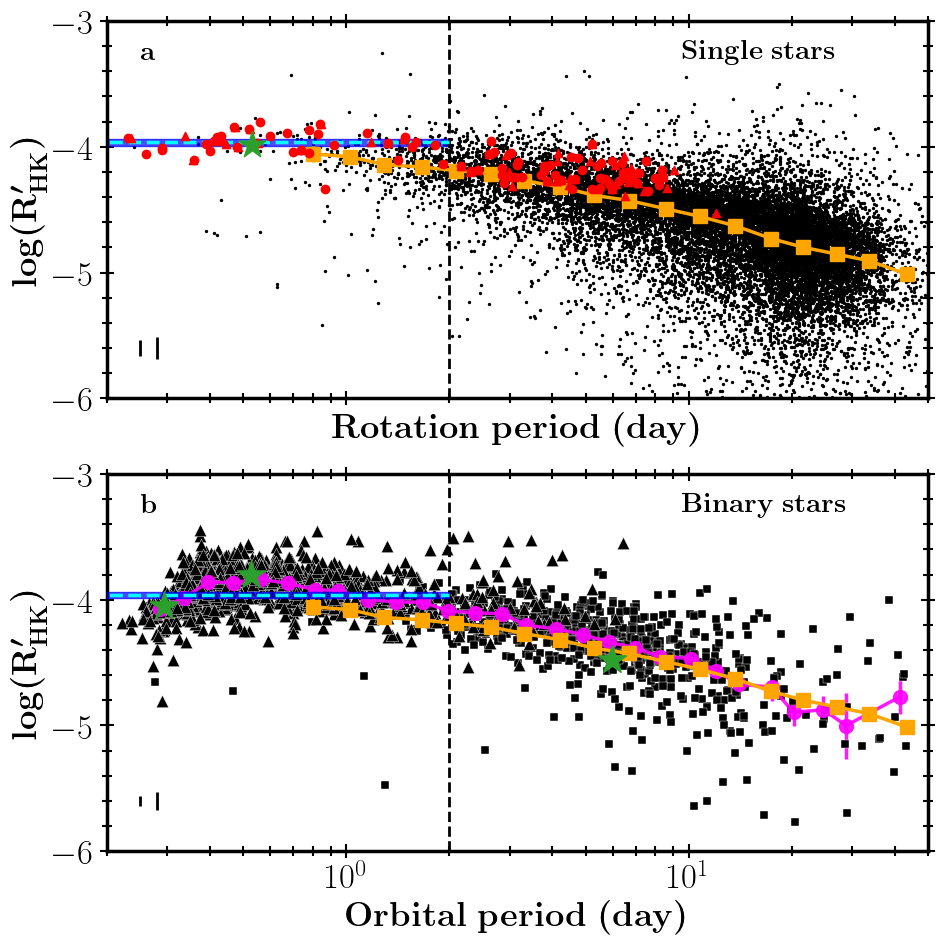

In [7]:
# calculate statistics and fit a line to the data
logRprimeHKSat = calibrator[calibrator.Prot<2].logrRprimehk.mean()
logRprimeHKSatErr = calibrator[calibrator.Prot<2].logrRprimehk.std()/np.sqrt(len(calibrator[calibrator.Prot<2]))
ErrInflationFactor = 2
print(f"Saturated logR'HK: {logRprimeHKSat:.3f}+/-{logRprimeHKSatErr:.3f}")
print("Number of rotators stars: {:d}".format(len(rotator[rotator.Prot.notna() & rotator.logrRprimehk.notna()])))

# calculate statistics and fit a line to the data
x = np.log10(rotator[~rotator.logrRprimehk.isna()].Prot.values)
y = rotator[~rotator.logrRprimehk.isna()].logrRprimehk.values
stat_rot_rhk = kepler.bin(x=x, y=y, bins=np.linspace(-0.15, 1.8, 20), suffixes=["P", "S"], LdivideN=True)
stat_rot_rhk = stat_rot_rhk.apply(pd.to_numeric)
stat_rot_rhk = stat_rot_rhk[(-2<stat_rot_rhk.median_P)&(stat_rot_rhk.median_P<1.7)&(stat_rot_rhk.N>10)]
shortP = pd.concat([rotator[["Prot", "logrRprimehk", "logrRprimehkerr"]], calibrator[["Prot", "logrRprimehk", "logrRprimehkerr"]]], axis=0, ignore_index=True)

# plot Prot vs Sindex
fig, ax = plt.subplots(2,1, figsize=(10,10), sharex=True, sharey=True)
ax[0].plot([0, 10**pthreshold], [logRprimeHKSat, logRprimeHKSat], c="cyan", ls="--", lw=2.5, zorder=3)
ax[0].fill_between([0, 10**pthreshold], y1=logRprimeHKSat-logRprimeHKSatErr*ErrInflationFactor, y2=logRprimeHKSat+logRprimeHKSatErr*ErrInflationFactor, color="blue", alpha=0.7, zorder=2)
ax[0].scatter(rotator.Prot, rotator.logrRprimehk, c="k", s=2, zorder=1)
ax[0].scatter(calibrator[calibrator.ref=="fang18"].Prot, calibrator[calibrator.ref=="fang18"].logrRprimehk, marker="^", s=35, c="r", zorder=4)
ax[0].scatter(calibrator[calibrator.ref=="wright11"].Prot, calibrator[calibrator.ref=="wright11"].logrRprimehk, marker="o", s=36, c="r", zorder=4)
ax[0].errorbar(10**stat_rot_rhk.median_P, stat_rot_rhk.median_S, marker="s", yerr=stat_rot_rhk.std_S, c="orange", zorder=3, lw=2.5, ms=10)
ax[0].set_ylabel(r"$\boldsymbol{\rm \log (R'_{HK})}$")
ax[0].set_xlabel(r"$\boldsymbol{\rm Rotation~period~(day)}$")
ax[0].errorbar([0.25], [-5.6], yerr=rotator.logrRprimehkerr.median(), c="k", zorder=12, ms=5, lw=2, marker='none')
ax[0].errorbar([0.28], [-5.6], yerr=rotator.logrRprimehkerrUniform.median(), c="k", zorder=12, ms=5, lw=2, marker='none')

kepler.figure_annotation(ax[0], text=[r"$\boldsymbol{\rm Single~stars}$"], fontsize=20, coords=[0.7, 0.90])
kepler.figure_annotation(ax[1], text=[r"$\boldsymbol{\rm Binary~stars}$"], fontsize=20, coords=[0.7, 0.90])
print("median uncertainties (with activiy variablity) for logR'HK of single stars: {:.3f}".format(rotator.logrRprimehkerrUniform.median()))
print("median formal uncertainties (without activiy variablity) for logR'HK of single stars: {:.3f}".format(rotator.logrRprimehkerr.median()))

# calculate statistics and fit a line to the data
x = np.log10(fullSample[~fullSample.logrRprimehk.isna()&(fullSample.eccentricity<ethreshold)].period.values)
y = fullSample[~fullSample.logrRprimehk.isna()&(fullSample.eccentricity<ethreshold)].logrRprimehk.values
starsShown = fullSample[~fullSample.logrRprimehk.isna()&(fullSample.eccentricity<ethreshold) & (fullSample.period.between(0.2, 50))]
print(f"Number of binary stars shown in this figure: {len(starsShown)}")
stat_bin_rhk = kepler.bin(x=x, y=y, bins=np.linspace(-0.6, 1.9, 33), suffixes=["P", "S"], LdivideN=True)
stat_bin_rhk = stat_bin_rhk.apply(pd.to_numeric)
stat_bin_rhk = stat_bin_rhk[(-2<stat_bin_rhk.median_P)&(stat_bin_rhk.median_P<1.7)&(stat_bin_rhk.N>5)]
print("Max logR'HK of binary stars is {:.3f}".format(stat_bin_rhk.median_S.max()))
ax[1].errorbar(10**stat_bin_rhk.median_P, stat_bin_rhk.median_S, yerr=stat_bin_rhk.std_S, marker="o", c="magenta", lw=2.5, ms=10, alpha=0.9)
ax[1].errorbar(10**stat_rot_rhk.median_P, stat_rot_rhk.median_S, yerr=stat_rot_rhk.std_S, marker="s", c="orange", zorder=5, lw=2.5, ms=10)
ax[1].set_xlabel(r"$\boldsymbol{\rm Orbital~period~(day)}$")
ax[1].set_ylabel(r"$\boldsymbol{\rm \log (R'_{HK})}$")

# show a single star in the saturated regime.
starID = "wright168"
ax[0].scatter(calibrator[calibrator.starID==starID].Prot, calibrator[calibrator.starID==starID].logrRprimehk, marker="*", s=395, c="tab:green", zorder=14, alpha=1)
print(f"Rotation period: {calibrator[calibrator.starID==starID].Prot.values[0]: .2f}")
# show a binary star in the supersatured regime.
uid = "G13310639495871"
ax[1].scatter(fullSample[fullSample.uid==uid].period, fullSample[fullSample.uid==uid].logrRprimehk, marker="*", s=450, c="tab:green", zorder=14, alpha=1)
print(f"Orbital period: {fullSample[fullSample.uid==uid].period.values[0]: .2f}")
# show a binary star in the saturated regime.
uid = "G16020328287173"
ax[1].scatter(fullSample[fullSample.uid==uid].period, fullSample[fullSample.uid==uid].logrRprimehk, marker="*", s=450, c="tab:green", zorder=14, alpha=1)
print(f"Orbital period: {fullSample[fullSample.uid==uid].period.values[0]: .2f}")
# show s binary star in the unsaturated regime.
uid = "G14644360021817"
ax[1].scatter(fullSample[fullSample.uid==uid].period, fullSample[fullSample.uid==uid].logrRprimehk, marker="*", s=450, c="tab:green", zorder=14, alpha=1)
print(f"Orbital period: {fullSample[fullSample.uid==uid].period.values[0]: .2f}")

cmap = plt.cm.get_cmap("gnuplot_r", 7)
cond = (fullSample.type.str.contains("SB"))& (fullSample.logrRprimehk.notna()) & (fullSample.eccentricity<ethreshold) & (fullSample.period.between(10**(-0.7), 10**1.7))
cb1 = ax[1].scatter(fullSample[cond].period, fullSample[cond].logrRprimehk, fc="black", ec="white", lw=0.3, s=28, zorder=2, marker="s")
print("{} SB binaries".format(len(fullSample[cond & (fullSample.period.between(0.2, 50))])))
cond = (fullSample.type.str.contains("Ec"))& (fullSample.logrRprimehk.notna())  & (fullSample.eccentricity<ethreshold) & (fullSample.period.between(10**(-0.7), 10**1.7))
cb1 = ax[1].scatter(fullSample[cond].period, fullSample[cond].logrRprimehk, fc="k", ec="white", lw=0.3, s=80, zorder=2, marker="^")
print("{} eclipsing binaries".format(len(fullSample[cond & (fullSample.period.between(0.2, 50))])))
ax[1].plot([0, 10**pthreshold], [logRprimeHKSat, logRprimeHKSat], c="cyan", ls="--", lw=2.5, zorder=11)
ax[1].fill_between([0, 10**pthreshold], y1=logRprimeHKSat-logRprimeHKSatErr*ErrInflationFactor, y2=logRprimeHKSat+logRprimeHKSatErr*ErrInflationFactor, color="blue", alpha=0.7, zorder=10)
for axis in ax: axis.axvline(10**pthreshold, ls="--", color="k", lw=2)
kepler.figure_annotation(ax, text=[r"$\boldsymbol{\rm a}$", r"$\boldsymbol{\rm b}$"], fontsize=20, coords=[0.04, 0.90])
ax[1].set_xlim(0.2, 50)
ax[1].set_ylim(-6, -3.0)
ax[0].set_xscale("log")
cond = (fullSample.logrRprimehk.notna()) & (fullSample.eccentricity<ethreshold) & (fullSample.period.between(10**(-0.7), 10**1.7))
ax[1].errorbar([0.25], [-5.6], yerr=fullSample[cond].logrRprimehkerr.median(), c="k", zorder=12, ms=5, lw=2, marker='none')
ax[1].errorbar([0.28], [-5.6], yerr=fullSample[cond].logrRprimehkerrUniform.median(), c="k", zorder=12, ms=5, lw=2, marker='none')
print("median uncertainties (with activiy variablity) for logR'HK of binary stars: {:.3f}".format(fullSample[cond].logrRprimehkerrUniform.median()))
print("median formal uncertainties (without activiy variablity) for logR'HK of binary stars: {:.3f}".format(fullSample[cond].logrRprimehkerr.median()))
print("enhancement is {:.2f} times formal uncertainty".format(0.16/0.38))
print("enhancement is {:.2f} times conservative uncertainty".format(0.16/0.070))
plt.tight_layout()
plt.subplots_adjust(hspace=0.20)
plt.savefig("../Figures/ProtRhkSingleBinaryStars.jpg", dpi=400, bbox_inches="tight", facecolor="w")
plt.savefig("../Figures/ProtRhkSingleBinaryStars.pdf", bbox_inches="tight", facecolor="w")


## Show binary and single stars in the supersaturated, saturated, and unsaturated regimes.

In [ ]:
def load_modify_spectrum(filename, rv, spectraVersion):
    """
    Process the saturated spectrum for a single star.
    Parameters:
    obsid (int): The observation ID of the star.
    meta (pd.DataFrame): Metadata containing filenames and observation IDs.
    rv (pd.DataFrame): Radial velocity data containing RV values and observation IDs.
    spectraVersion (str): Version of the spectra to load.
    CaIIKLambda0 (float): Rest wavelength of the Ca II K line.
    lightspeed (float): Speed of light, typically in km/s.

    Returns:
    dict: Processed data containing the loaded spectrum, radial velocity, and wavelength offset.
    """
    # For measuring S index.
    lightspeed = 299792.458                 # the speed of light in vacuum in units of km/s
    CaIIKLambda0 = 3933.664                 # CaII K line wavelength in air
    # Load the saturated spectrum.
    spec = specKit.load_lamost_spectra(filename, spectraVersion)
    # Calculate the wavelength offset for the saturated spectrum.
    CaIIKLambdaObs = CaIIKLambda0 * (1 + rv / lightspeed)
    waveOffset = CaIIKLambdaObs - CaIIKLambda0
    spec["wavelength"] = spec["wavelength"] - waveOffset
    return spec

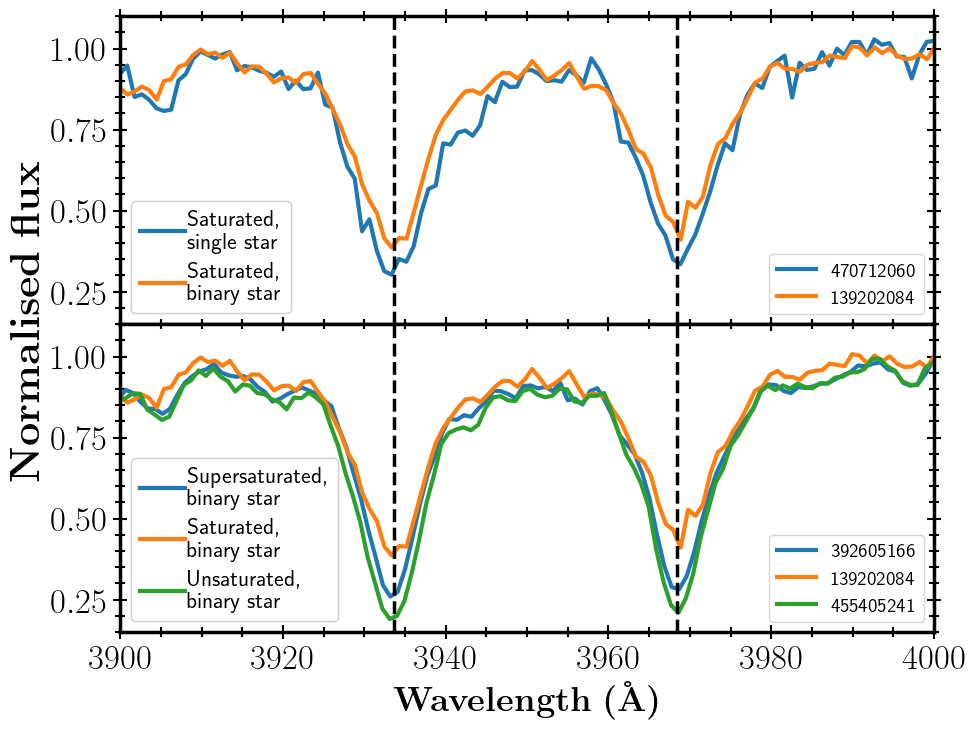

In [9]:
# load spectra for a saturated single star and a saturated single star and shift wavelength into rest frame.
saturatedSingleobsid = 470712060
rv=95.8644 
filename = "../Data/spec-57662-KP034215N224711V01_sp12-060.fits.gz"
specSaturatedSingle = load_modify_spectrum(filename, rv, "v9")

saturatedBinaryobsid = 139202084 
rv = 163.307 
filename = "../Data/spec-56380-GAC126N02V1_sp02-084.fits.gz"
specSaturatedBinary = load_modify_spectrum(filename, rv, "v9")

supersaturatedBinaryobsid = 392605166
rv = 107.8997 
filename = "../Data/spec-57378-EG233555N275153V01_sp05-166.fits.gz"
specSuperaturatedBinary = load_modify_spectrum(filename, rv, "v9")


unsaturatedBinaryobsid = 455405241
rv = 44.527 
filename = "../Data/spec-57502-HD124414N514533V01_sp05-241.fits.gz"
specUnsaturatedBinary = load_modify_spectrum(filename, rv, "v9")

fig, ax = plt.subplots(2, 1, figsize=(10.5, 8), sharex=True, sharey=True)
line1, = ax[0].plot(specSaturatedSingle.wavelength, specSaturatedSingle.fluxnorm / 0.9, label="Saturated, \n single star", lw=3)
line2, = ax[0].plot(specSaturatedBinary.wavelength, specSaturatedBinary.fluxnorm / 0.9, label="Saturated, \n binary star", lw=3)
ax[0].axvline(x=CaIIKLambda0, color="k", linestyle="--", lw=2.5)
ax[0].axvline(x=CaIIHLambda0, color="k", linestyle="--", lw=2.5)
# Add legends to the first subplot
ax[0].add_artist(ax[0].legend([line1, line2], ["470712060", "139202084"], loc="lower right", fontsize=14))  # Keep this legend
ax[0].add_artist(ax[0].legend(fontsize=16, loc="lower left", labelspacing=0.4, handletextpad=0.1))  # Add a second legend
# Plot for the second subplot
line3, = ax[1].plot(specSuperaturatedBinary.wavelength, specSuperaturatedBinary.fluxnorm, label="Supersaturated, \n binary star", lw=3)
line4, = ax[1].plot(specSaturatedBinary.wavelength, specSaturatedBinary.fluxnorm / 0.9, label="Saturated, \n binary star", lw=3)
line5, = ax[1].plot(specUnsaturatedBinary.wavelength, specUnsaturatedBinary.fluxnorm, label="Unsaturated, \n binary star", lw=3)
ax[1].add_artist(ax[1].legend([line3, line4, line5], ["392605166", "139202084", "455405241"], loc="lower right", fontsize=14))  # Keep this legend
ax[1].add_artist(ax[1].legend(fontsize=16, loc="lower left", labelspacing=0.4, handletextpad=0.1))  # Add a second legend

ax[1].axvline(x=CaIIKLambda0, color="k", linestyle="--", lw=2.5)
ax[1].axvline(x=CaIIHLambda0, color="k", linestyle="--", lw=2.5)
ax[0].set_xlim(3900, 4000)  
ax[0].set_ylim(0.15, 1.1)
ax[1].set_xlabel(r"$\boldsymbol{\rm Wavelength~(\AA)}$")
fig.supylabel(r"$\boldsymbol{\rm Normalised~flux}$")
plt.subplots_adjust(hspace=0.0)
plt.savefig("../Figures/ExampleSpectra.jpg", dpi=400, bbox_inches="tight")
plt.savefig("../Figures/ExampleSpectra.pdf", dpi=400, bbox_inches="tight")